In [6]:
import os
from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# This notebook visualizes day-wise actual versus predicted PV power on the test set for the best XGBoost configuration.

# The working directory of this notebook is assumed to be "4. Visualization".
BASE_DIR = os.path.dirname(os.getcwd())
RESULTS_REL_PATH = os.path.join(
    "3. XGBoost Training",
    "xgb_hyangrin_results",
    "holdout",
    "window_flatten",
    "win_16",
    "high_none_low_0.3",
)
TEST_PRED_PATH = os.path.join(BASE_DIR, RESULTS_REL_PATH, "test_predictions.csv")

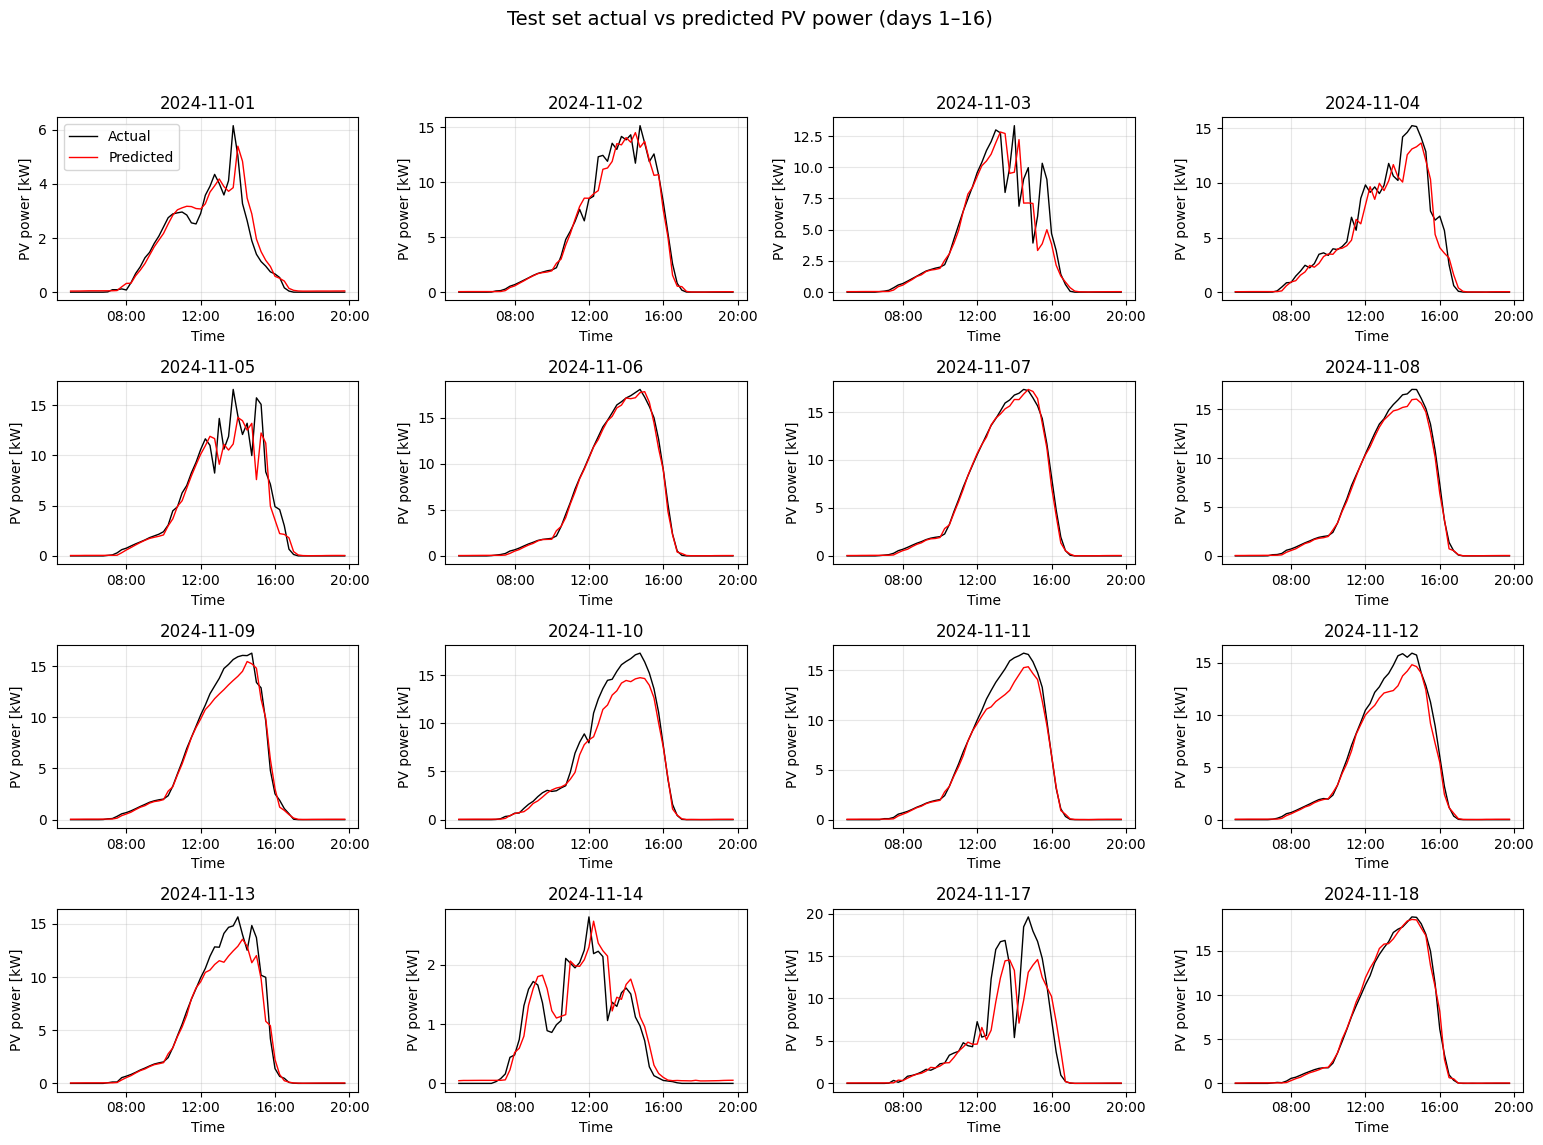

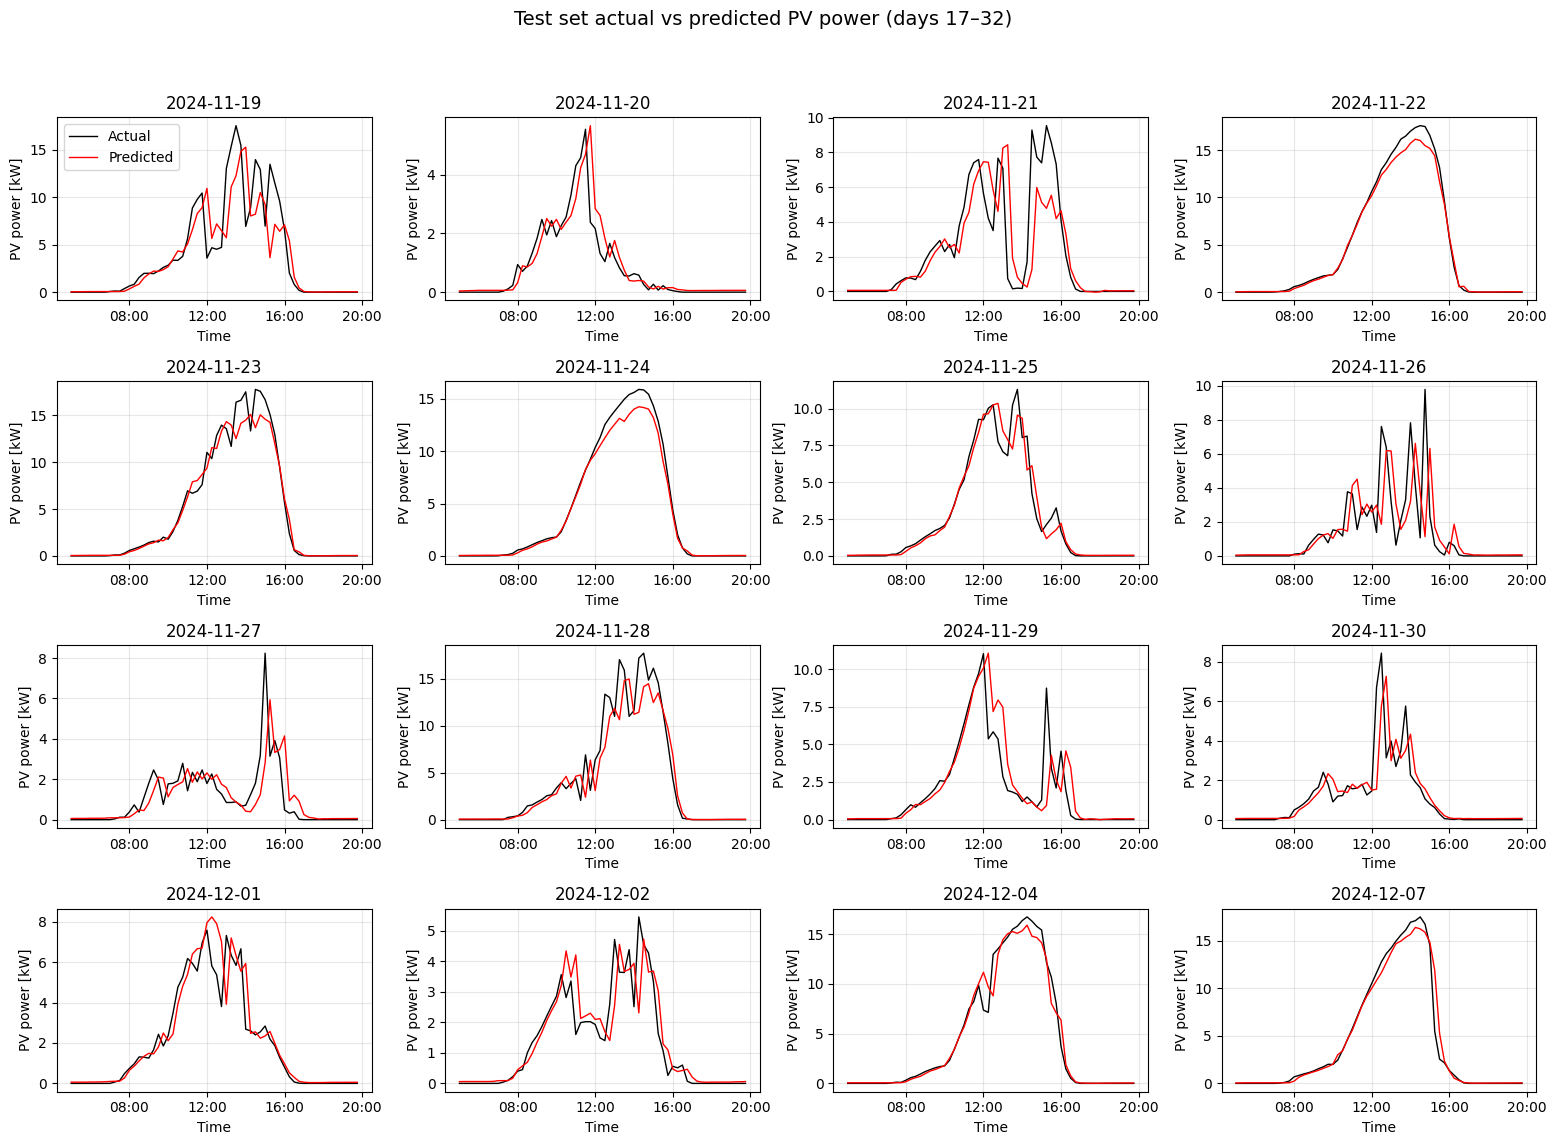

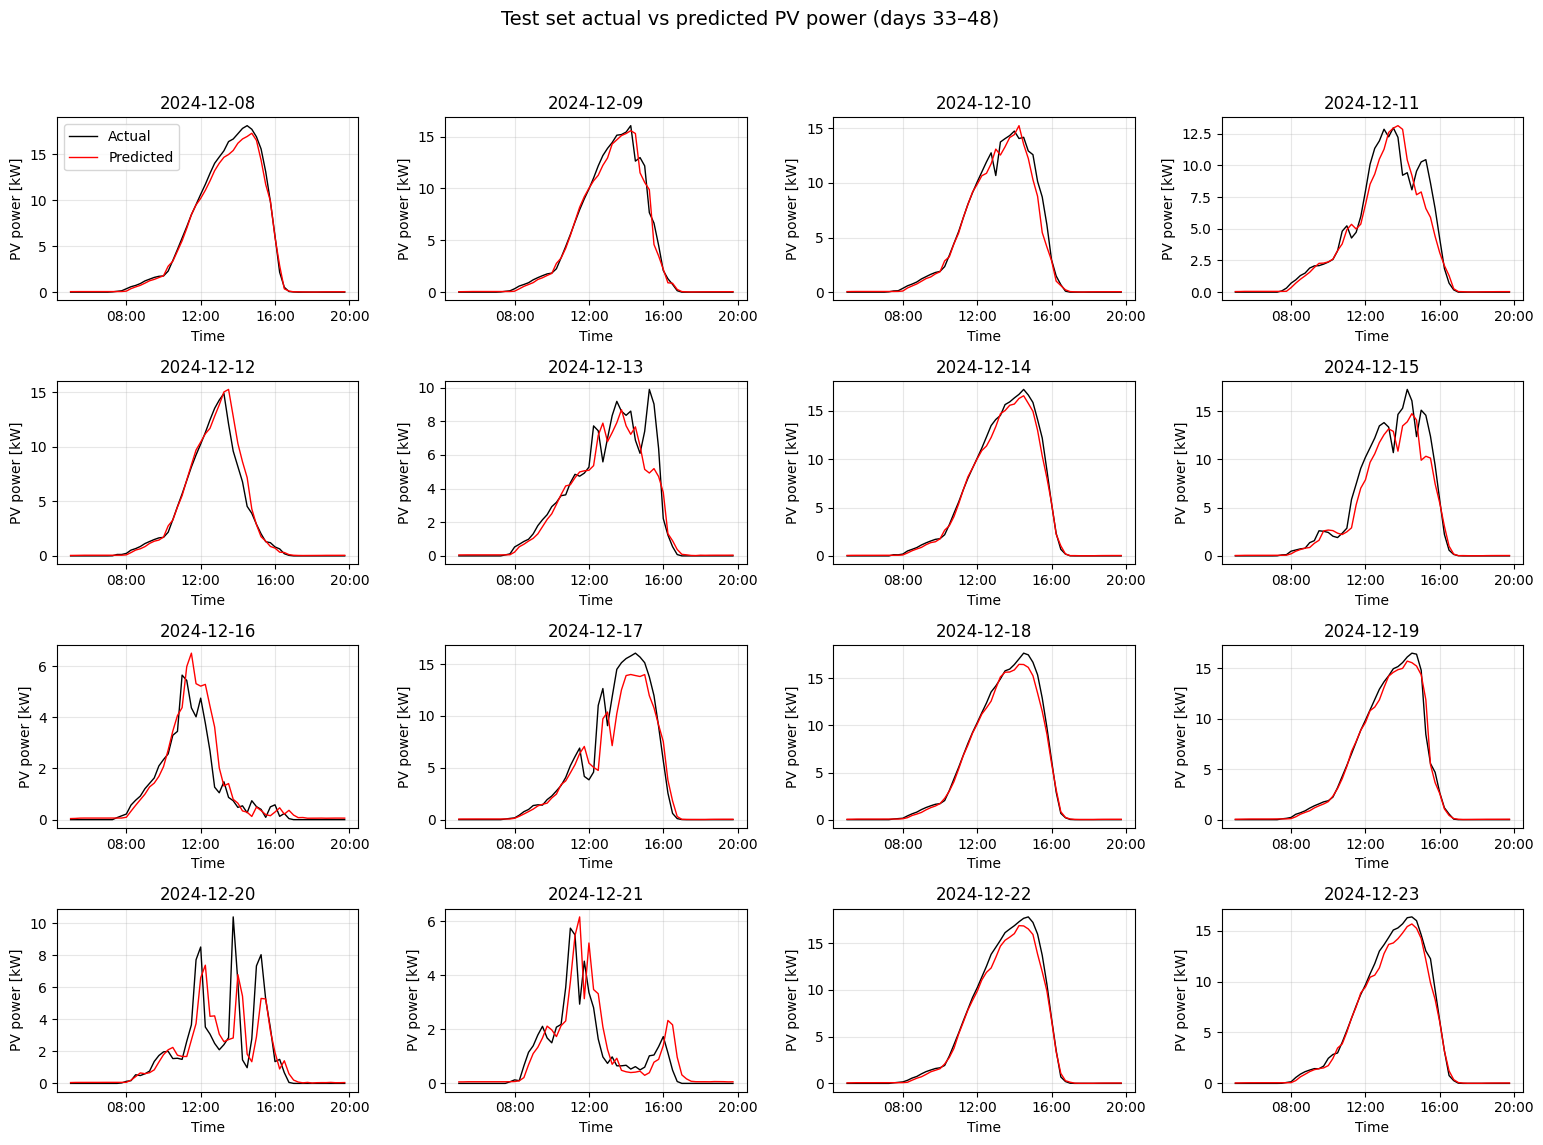

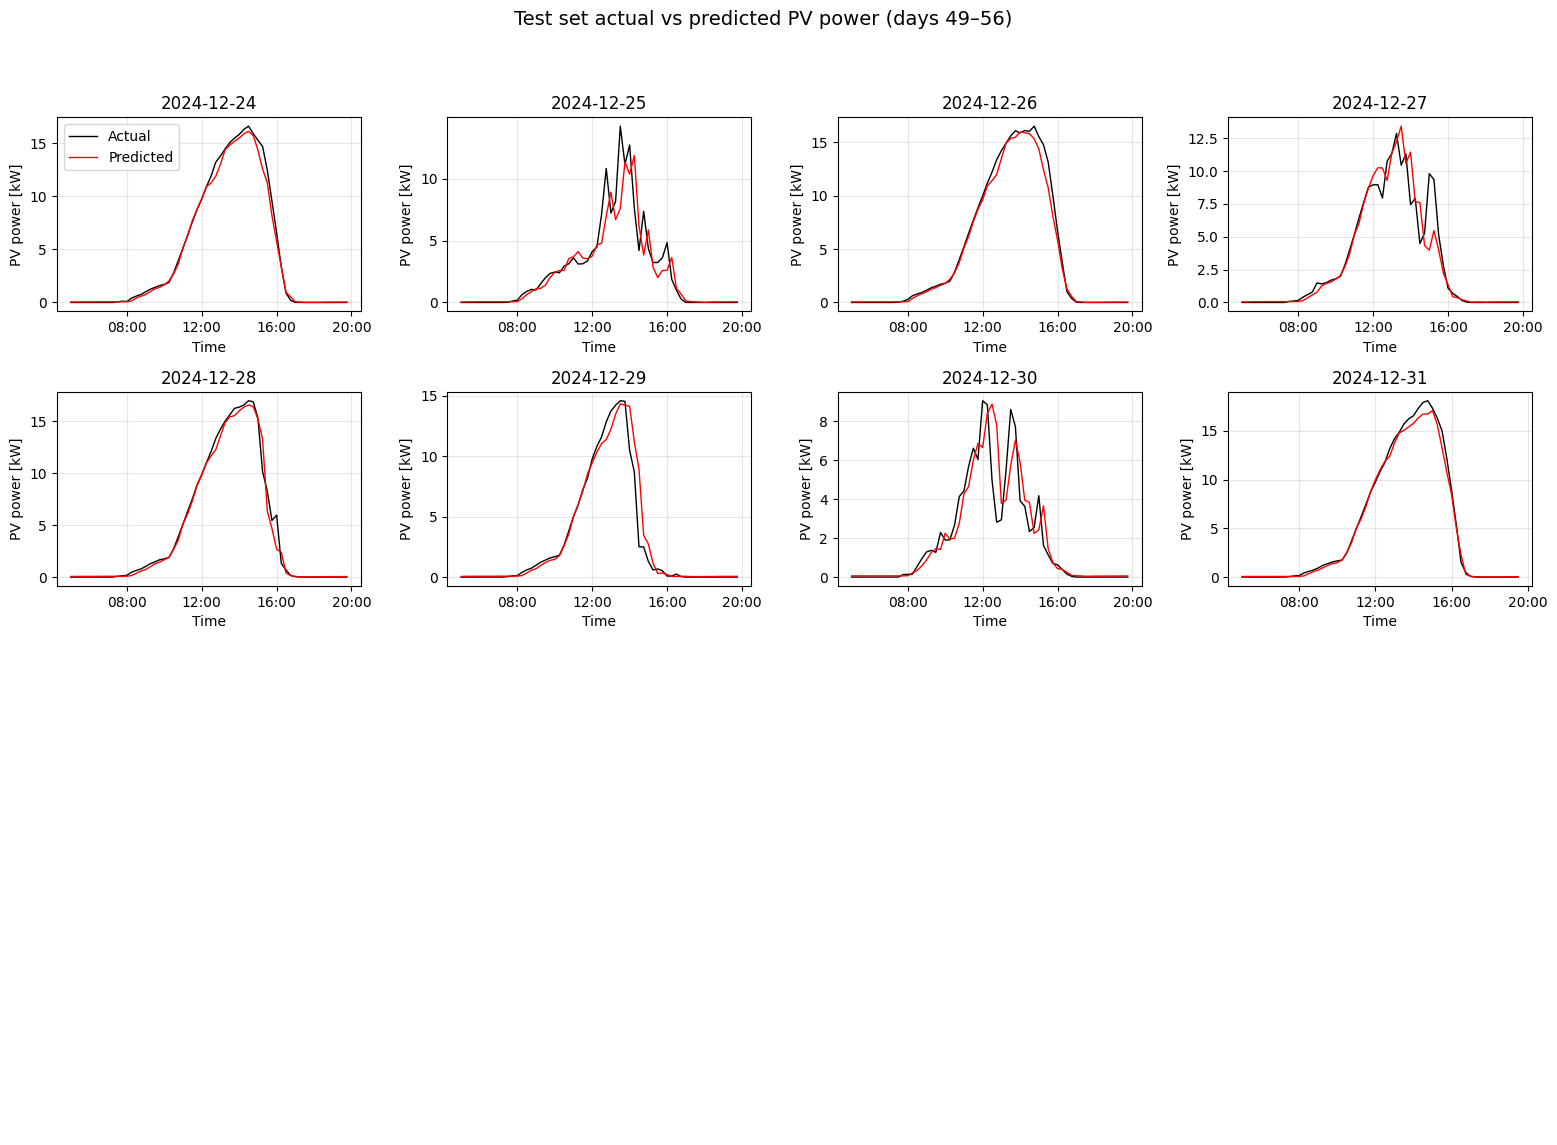

In [7]:
# Load test-set predictions for the best configuration
pred_df = pd.read_csv(TEST_PRED_PATH)

# Parse datetime information and sort chronologically
pred_df["datetime"] = pd.to_datetime(pred_df["datetime"], errors="coerce")
pred_df = pred_df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# Sanity check of available columns
expected_cols = {"datetime", "month", "day", "hour", "minute", "y_true_kw", "y_pred_kw"}
missing_cols = expected_cols.difference(pred_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in test_predictions.csv: {sorted(missing_cols)}")


def plot_daily_actual_vs_pred(
    df: pd.DataFrame,
    days_per_figure: int = 16,
    n_rows: int = 4,
    n_cols: int = 4,
    title_prefix: str = "Test set actual vs predicted PV power",
) -> None:
    """Generate day-wise actual versus predicted plots in 4x4 grids over the test period."""
    df = df.copy()
    df["date"] = df["datetime"].dt.date

    grouped = list(df.groupby("date"))
    n_days = len(grouped)
    if n_days == 0:
        raise ValueError("No daily groups available for plotting.")

    n_figures = int(np.ceil(n_days / days_per_figure))

    for fig_idx in range(n_figures):
        start = fig_idx * days_per_figure
        end = min((fig_idx + 1) * days_per_figure, n_days)
        days_chunk = grouped[start:end]

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(n_cols * 4.0, n_rows * 3.0),
            sharex=False,
            sharey=False,
        )
        axes = axes.flatten()

        for ax_idx, ax in enumerate(axes):
            if ax_idx < len(days_chunk):
                day, df_day = days_chunk[ax_idx]

                ax.plot(
                    df_day["datetime"],
                    df_day["y_true_kw"],
                    label="Actual",
                    color="black",
                    linewidth=1.0,
                )
                ax.plot(
                    df_day["datetime"],
                    df_day["y_pred_kw"],
                    label="Predicted",
                    color="red",
                    linewidth=1.0,
                )

                ax.set_title(str(day))
                ax.set_xlabel("Time")
                ax.set_ylabel("PV power [kW]")
                ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
                ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
                ax.grid(alpha=0.3)

                if ax_idx == 0:
                    ax.legend()
            else:
                ax.axis("off")

        fig.suptitle(
            f"{title_prefix} (days {start + 1}–{end})",
            fontsize=14,
        )
        fig.tight_layout(rect=[0.02, 0.03, 1.0, 0.95])
        plt.show()


# Generate 4x4 day-wise figures over the entire test period
plot_daily_actual_vs_pred(pred_df, days_per_figure=16, n_rows=4, n_cols=4)